<a href="https://colab.research.google.com/github/hwayoungc24-rgb/younghwa/blob/main/TSLA_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
# 데이터 로딩
file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
df = pd.read_csv(file_path, index_col=0)

df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500


In [38]:
df = df[['Open']]
df

,Open
Date,
2010-06-29,3.800000
2010-06-30,5.158000
2010-07-01,5.000000
2010-07-02,4.600000
2010-07-06,4.000000
...,...
2022-03-18,874.489990
2022-03-21,914.979980
2022-03-22,930.000000


In [39]:
openValues = df[['Open']]

In [40]:
# 특징값 정규화
# 신경망의 입력은 0-1 사이의 실수여야 함
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0,1))
scaled = scaler.fit_transform(openValues)

In [41]:
scaled.shape

(2956, 1)

In [42]:
# 훈련 데이터와 테스트 데이터의 분리
TEST_SIZE = 2400
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:] # 후반부의 2400개를 테스트 데이터로 사용

In [43]:
train_data.shape

(556, 1)

In [44]:
# 순차 훈련 데이터 생성
def make_sample(data, window):
    train = []
    target = []

    for i in range(len(data)-window):
        train.append(data[i:i+window])
        target.append(data[i+window])

    return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 100)
X_train.shape, y_train.shape

((456, 100, 1), (456, 1))

In [45]:
# SimpleRNN 모델 구축하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN

model = Sequential()
model.add(SimpleRNN(16, input_shape=(X_train.shape[1], 1), activation='tanh', return_sequences=False))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
# 모델 학습
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(X_train, y_train, epochs = 10, batch_size = 16)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.3228e-04
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.4148e-06
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.2218e-06
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.9721e-06
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.8450e-06
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8037e-06
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7575e-06
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.7168e-06
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6846e-06
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.6471e-06


In [47]:
# 테스트셋을 이용하여 미래 주가 예측
X_test, y_test = make_sample(test_data, 100)
pred = model.predict(X_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


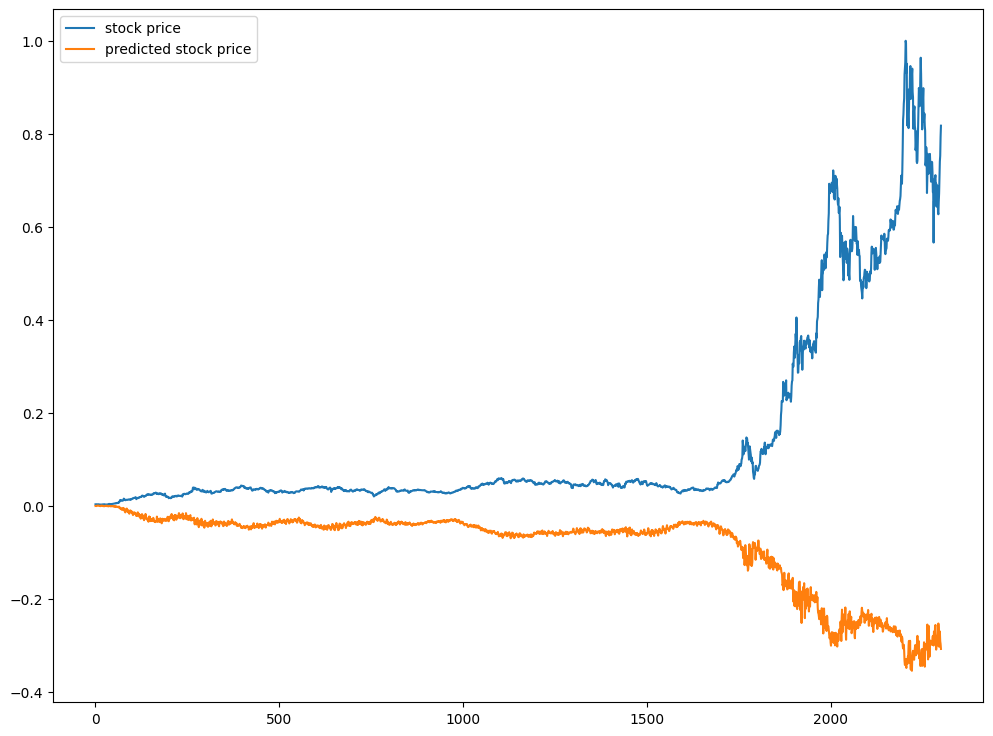

In [48]:
# 그래프 그리기
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.plot(y_test, label='stock price')
plt.plot(pred, label='predicted stock price')
plt.legend()
plt.show()

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("R² score:", r2_score(y_test, pred))

MSE: 0.14409637604808065
MAE: 0.22544802866100283
R² score: -1.9581731541985654
